In [29]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage
from langchain_core.messages.base import BaseMessage
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver

In [30]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [31]:
class ChatBotState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [32]:
def chat_node(state: ChatBotState)-> ChatBotState:
    #print initial state for log
    messages = state['messages']
    print(messages)

    responce = llm.invoke(messages)

    return {"messages": responce}

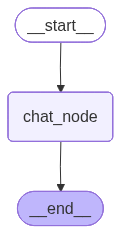

In [33]:
graph = StateGraph(ChatBotState)
checkpointer = MemorySaver()

# Add Node
graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [35]:
from IPython.core.magics import config
initial_state = {"messages": HumanMessage(content="Hii, my name is poojan solanki")}
config = {'configurable': {"thread_id": 1}}
final_state = workflow.invoke(initial_state, config=config)

[HumanMessage(content='Hii, my name is poojan solanki', additional_kwargs={}, response_metadata={}, id='b69dc5b6-fc4b-4dce-a38b-623186b6d711')]


In [19]:
final_state

{'messages': [HumanMessage(content='Hii, my name is poojan solanki', additional_kwargs={}, response_metadata={}, id='f2cde0b5-88b7-4dc5-8fe8-429e50a204ec'),
  AIMessage(content=[{'type': 'text', 'text': 'Hello, Poojan Solanki! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EjQKMgEMOdbHRPKu0Az5AMj+ptnk8Jtow8wIrQvgBYKxHdHRJ/dVQkRAjb6X5mLnFicnaSfX'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec02e-3660-7c80-84f0-0cb9cd56cece-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 30, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}})]}

In [38]:
initial_state_2 = {"messages": HumanMessage(content="but i am not rajput, i am a tailor")}
final_state_2 = workflow.invoke(initial_state_2, config=config )

[HumanMessage(content='Hii, my name is poojan solanki', additional_kwargs={}, response_metadata={}, id='b69dc5b6-fc4b-4dce-a38b-623186b6d711'), AIMessage(content=[{'type': 'text', 'text': 'Hello, Poojan Solanki! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EjQKMgEMOdbHuaDcXR5a1xbRlPKwaLe/eE32A62+Fge6zgHozPfjqxI8qCsrtBH7NiH3xPZV'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec044-89ff-71c0-990c-899510a4ef4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 30, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='so can you tell me my surname?', additional_kwargs={}, response_metadata={}, id='ae7f75f5-89f9-4d9e-9f61-16fe06b82ac8'), AIMessage(content=[{'type': 'text', 'text': 'Your surname is **Solanki**.\n\nIt

In [39]:
final_state_2

{'messages': [HumanMessage(content='Hii, my name is poojan solanki', additional_kwargs={}, response_metadata={}, id='b69dc5b6-fc4b-4dce-a38b-623186b6d711'),
  AIMessage(content=[{'type': 'text', 'text': 'Hello, Poojan Solanki! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EjQKMgEMOdbHuaDcXR5a1xbRlPKwaLe/eE32A62+Fge6zgHozPfjqxI8qCsrtBH7NiH3xPZV'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec044-89ff-71c0-990c-899510a4ef4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 30, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='so can you tell me my surname?', additional_kwargs={}, response_metadata={}, id='ae7f75f5-89f9-4d9e-9f61-16fe06b82ac8'),
  AIMessage(content=[{'type': 'text', 'text': 'Your surname is

In [44]:
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Hii, my name is poojan solanki', additional_kwargs={}, response_metadata={}, id='b69dc5b6-fc4b-4dce-a38b-623186b6d711'), AIMessage(content=[{'type': 'text', 'text': 'Hello, Poojan Solanki! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EjQKMgEMOdbHuaDcXR5a1xbRlPKwaLe/eE32A62+Fge6zgHozPfjqxI8qCsrtBH7NiH3xPZV'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec044-89ff-71c0-990c-899510a4ef4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 30, 'total_tokens': 41, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='so can you tell me my surname?', additional_kwargs={}, response_metadata={}, id='ae7f75f5-89f9-4d9e-9f61-16fe06b82ac8'), AIMessage(content=[{'type': 'text', 'text': '